<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustering_all_mpnet_base_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
### **Topic modelling by embedding vector space with **all-mpnet-base-v2****

In this notebook Turftopics library used for topic modelling and clustering. Turftopic is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

**SentenceTransformer:** This is a class from the sentence_transformers module, which is part of the sentence-transformers Python library. This class provides functionality to convert sentences or text passages into numerical representations (vectors) using pre-trained transformer models.

The **"all-MiniLM-L6-v2"** is a sentence-transformers model: It maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search.


This model can then be used to encode or embed sentences into fixed-dimensional vectors, which can be useful for tasks such as semantic similarity comparison, clustering, or classification. It can be used for tasks like clustering, semantic search, and information retrieval. With its ability to capture semantic information, it's particularly effective for tasks such as sentence similarity and clustering. The model was fine-tuned on a massive dataset of over 1 billion sentence pairs using a self-supervised contrastive learning objective, leveraging the pre-trained microsoft/mpnet-base model. This means it can handle large-scale data with ease and achieve impressive results in information retrieval, clustering, and sentence similarity tasks.


---




## **Step 1: Install Packages and Import Required Libraries**

This step focuses on preparing the environment for topic modeling and data analysis. Here's what you did:

1. **Package Installation**:

   * Installed the `turftopic` package with optional dependencies like `umap-learn` and `datamapplot`, which are essential for dimensionality reduction and visualization.

2. **Library Imports**:

   * Imported standard data processing and visualization libraries: `numpy`, `pandas`, `seaborn`, `matplotlib`, and `torch`.
   * Imported libraries for topic modeling using pre-trained transformer models:

     * `SentenceTransformer` from `sentence_transformers` for sentence embeddings.
     * `AutoTokenizer` and `AutoModel` from `transformers` for tokenizing and encoding text data.
     * `Top2Vec` and `BERTopic` from `turftopic` for topic clustering.
   * Imported clustering and visualization tools:

     * `linkage` and `dendrogram` from `scipy.cluster.hierarchy` for hierarchical clustering visualization.
     * `cosine_distances` from `sklearn.metrics.pairwise` for distance calculations.
   * Imported evaluation metrics:

     * `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score` from `sklearn.metrics` to assess clustering quality.

This step ensures that all necessary components are in place to proceed with topic modeling and analysis.

---


In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

In [ ]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import Top2Vec
from turftopic import BERTopic

# Required libraries for dendrogram and visualisation
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Google drive library
from google.colab import drive
drive.mount('/content/drive')

## **Step 2: Load and Read from the Original Dataset**

This step is about acquiring and inspecting the dataset for further analysis. Here's what was done:

1. **Dataset Source**:

   * A sample dataset of 10,000 PubMed abstracts was loaded, including metadata such as titles and publication years. The dataset was sourced from a Graph Database and accessed via a file path.

2. **File Loading**:

   * Used `pandas.read_csv` to load the dataset from Google Drive:


3. **Initial Exploration**:

   * Printed the dataset’s shape and content to understand its structure.
   * Isolated the `abstract` column, dropping any rows with missing data and resetting the index:
   * Displayed a few samples from the cleaned dataset to verify correct loading.
   * Called `dataset.info()` to summarize the dataset structure, including column names, data types, and missing values.

This step successfully loads and prepares the textual data (abstracts) for embedding and topic modeling in later steps.

---


In [ ]:
### --- Option 1: Google Drive --- ###
# Read and Load dataset from Google Drive
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

# ### --- Option 1: Google Clab (Any Other online platform) --- ###
# # Read and Load dataset from root
# dataset = pd.read_csv('sample_PubMedDataAbstracts.csv')

# # Show the datasets
# ### Abstract Embeddings Sample Dataset
# print('Node Content:', dataset.shape)
# print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [ ]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].dropna().reset_index(drop=True)

# Display a few samples to verify
print(abstracts)

# Check the dataset
print(dataset.info())

0       Background Niemann-Pick disease type C (NPC) i...
1       Background Metformin toxicity is well known to...
2       Background Measuring service use and costs is ...
3       Background Substance use and delinquency are c...
4       Objectives Intravenous fluids are one of the m...
                              ...                        
9995    The distribution of methylmercury (MeHg) and t...
9996    The purpose of this study was to examine the s...
9997    Infectious disease occurs when a person is inf...
9998    Spinal cord injury (SCI) is a severe traumatic...
9999    Abiotic stresses greatly influenced wheat prod...
Name: abstract, Length: 10000, dtype: object


## **Step 2: Load and Read from the Original Dataset**

This step is about acquiring and inspecting the dataset for further analysis. Here's what was done:

1. **Dataset Source**:

   * A sample dataset of 10,000 PubMed abstracts was loaded, including metadata such as titles and publication years. The dataset was sourced from a Graph Database and accessed via a file path.

2. **File Loading**:

   * Used `pandas.read_csv` to load the dataset from Google Drive:


3. **Initial Exploration**:

   * Printed the dataset’s shape and content to understand its structure.
   * Isolated the `abstract` column, dropping any rows with missing data and resetting the index:
   * Displayed a few samples from the cleaned dataset to verify correct loading.
   * Called `dataset.info()` to summarize the dataset structure, including column names, data types, and missing values.

This step successfully loads and prepares the textual data (abstracts) for embedding and topic modeling in later steps.

---


## **Step 3: Extract Embeddings using `all-MiniLM-L6-v2`**

This step involves converting textual data (abstracts) into numerical representations (embeddings) that can be used for clustering and topic modeling. Here's what you did:

1. **Model Selection**:

   * You used the pre-trained model **`all-MiniLM-L6-v2`** from the `SentenceTransformer` library. This model is efficient and widely used for generating dense sentence embeddings suitable for semantic similarity and clustering tasks.

2. **Embedding Generation**:

   * Passed the cleaned list of abstracts to the `encode` method:
   * The method returns a NumPy array where each row represents the embedding of one abstract. The use of `show_progress_bar=True` provides visual feedback during the process.

3. **Verification**:

   * Printed the resulting embeddings and their shape to confirm successful encoding and to understand the dimensions of the resulting matrix. Each embedding vector likely has a dimensionality of 384 (standard for `all-MiniLM-L6-v2`).

This step transforms your textual dataset into a format that can be used for unsupervised learning techniques like clustering and topic modeling in subsequent steps.

---

In [ ]:
# Using TurfTopic default encoder to extract embedding of the dataset
encoder = SentenceTransformer("all-mpnet-base-v2")
embeddings = encoder.encode(abstracts, show_progress_bar=True)

In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[ 0.04792419  0.01959507  0.02696265 ... -0.0258829  -0.01593075
  -0.03001085]
 [ 0.00446342 -0.03347765  0.04773438 ... -0.00294993 -0.01502673
  -0.02959536]
 [ 0.05305922  0.04325606 -0.01718555 ...  0.05402481 -0.03447898
   0.00759281]
 ...
 [ 0.00898637  0.08041715 -0.02025051 ...  0.02268609 -0.0154812
  -0.05780742]
 [ 0.01377237 -0.03108529  0.01784439 ... -0.04156252 -0.04256187
  -0.03677319]
 [-0.08398326 -0.03766333  0.00174437 ...  0.00302392 -0.04151252
  -0.01138049]] 

 (10000, 768)


In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=encoder, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [ ]:
topic_data

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (114, 10027)
├── document_topic_matrix (10000, 114)
├── document_representation (10000, 768)
├── transform
├── topic_names (114)
├── has_negative_side
└── hierarchy

In [ ]:
topic_data.topic_term_matrix

array([[ 3.80497439e-02,  2.97779267e-02,  4.80015603e-02, ...,
        -1.48372087e-03, -1.65074277e-02,  9.21209461e-02],
       [ 6.28691560e-02,  4.96991170e-02,  4.34382251e-02, ...,
         1.26685597e-02,  2.24835011e-02,  2.26327892e-02],
       [ 4.72374535e-02,  3.80857543e-02,  1.91025213e-02, ...,
         1.22853156e-02,  5.07129392e-05,  1.72836695e-02],
       ...,
       [ 1.16794773e-01,  7.56910703e-02,  9.34069152e-02, ...,
         1.81754846e-02,  3.94360021e-02,  3.61126606e-02],
       [ 1.21839987e-01,  8.92954620e-02,  6.88701904e-02, ...,
         1.52582401e-02,  3.52356096e-02,  2.25120328e-02],
       [ 9.77873267e-02,  7.30194702e-02,  4.27679516e-02, ...,
         1.73557527e-02,  8.92750737e-03,  2.59664571e-02]])

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ biomarkers, biomarker, biochemistry, carcinogenesis, transcriptomic, metabolomic,                    │
│          │ immunocytochemistry, proteomic, cytotoxicity, pathogenesis                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ retinopathy, glaucoma, intraocular, cataract, ophthalmic, macular, corneal, retinal, ocular, eye     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ infertility, intrauterine, infertile, ivf, fertility, endometrial, endometriosis, ovulation,         │
│          │ blastocyst, ovarian                                                                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ sensors, sensor, accelerometers, sensing, iot, accelerometer, classifiers, biosensor, svm, gps       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ insecticides, insecticide, pesticides, insect, insects, larvae, drosophila, peptides,                │
│          │ transcriptomic, metabolomic                                                                          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ lignocellulosic, lignin, biomass, cellulose, hydrolase, polysaccharides, hydrolysates, hydroxylase,  │
│          │ polysaccharide, glycolysis                                                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ dental, teeth, periodontal, periodontitis, gingival, tooth, caries, epidemiologic, epidemiology,     │
│          │ mouth                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ dental, teeth, periodontal, tooth, periodontitis, enamel, gingival, resin, dent, maxillary           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ periodontitis, periodontal, gingival, dental, biofilms, caries, antimicrobials, teeth, biofilm,      │
│          │ antimicrobial                                                                                        │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ toxins, aquaculture, toxicological, neurotoxicity, metabolomic, cytotoxicity, fish, biochemical,     │
│          │ toxin, metabolomics                                                                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ candidiasis, candida, antifungal, aspergillus, yeasts, fungal, pathogens, fungus, saccharomyces,     │
│          │ yeast                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ leishmaniasis, trypanosoma, proteases, pathogenesis, parasites, phagocytosis, pathogens, protease,   │
│          │ malaria, pathogen                          

In [ ]:
# Cluster model hierarchy
model.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

Root: 
├── -1: biomarkers, biomarker, biochemistry, carcinogenesis, transcriptomic, metabolomic, 
│   immunocytochemistry, 
│   proteomic, cytotoxicity, pathogenesis
├── 2: sensors, sensor, accelerometers, sensing, iot, accelerometer, classifiers, biosensor, svm, 
│   gps
├── 114: phytochemicals, flavonoids, phytochemical, flavonoid, antioxidative, phenolics, antioxidants,
│   polyphenols, 
│   antioxidant, ingredients
│   ├── 31: surfactants, bioavailability, solvents, cyclodextrin, glycosides, surfactant, hydrogels,
│   │   pharmacokinetics, 
│   │   flavonoids, glycosylation
│   └── 36: phytochemicals, flavonoids, phytochemical, flavonoid, antioxidative, phenolics, 
│       antioxidants, polyphenols, 
│       antioxidant, ingredients
├── 126: cognition, psychology, stimuli, fmri, cognitive, cognitively, neurocognitive, perception, 
│   neuropsychological, 
│   inhibition
│   ├── 75: judgments, judgment, acceptability, ethics, beliefs, responsibility, intentions, 
│   │   phenomenolo

In [ ]:
# Model hierarchy after merging topics
fig = model.hierarchy[190].plot_tree()
fig.show()

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **2. TurfTopic Default model and configuration**
  - Use "all-MiniLM-L6-v2" to extract embeddings
  - Use BERTopic to topic modelling ans clustering

In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[ 0.04792419  0.01959507  0.02696265 ... -0.0258829  -0.01593075
  -0.03001085]
 [ 0.00446342 -0.03347765  0.04773438 ... -0.00294993 -0.01502673
  -0.02959536]
 [ 0.05305922  0.04325606 -0.01718555 ...  0.05402481 -0.03447898
   0.00759281]
 ...
 [ 0.00898637  0.08041715 -0.02025051 ...  0.02268609 -0.0154812
  -0.05780742]
 [ 0.01377237 -0.03108529  0.01784439 ... -0.04156252 -0.04256187
  -0.03677319]
 [-0.08398326 -0.03766333  0.00174437 ...  0.00302392 -0.04151252
  -0.01138049]] 

 (10000, 768)


In [ ]:
# import BERTopic library
from turftopic import BERTopic

In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder=encoder, random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings)

In [ ]:
topic_data1

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (185, 10027)
├── document_topic_matrix (10000, 185)
├── document_representation (10000, 768)
├── transform
├── topic_names (185)
├── has_negative_side
└── hierarchy

In [ ]:
topic_data1.topic_term_matrix

array([[125.93954949, 377.78287229,  33.60433448, ...,  75.41096483,
        311.81407699,  86.1839598 ],
       [ 24.37539668,   6.5134978 ,   0.        , ...,   0.        ,
         74.83537848,   0.        ],
       [ 32.5005289 ,   3.2567489 ,  11.20144483, ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          3.11814077,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
         12.47256308,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ study, patients, results, cells, using, associated, analysis, data, health, used                     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ eyes, retinal, oct, eye, bcva, corneal, amd, glaucoma, macular, iop                                  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ pregnancy, embryo, ivf, embryos, ovarian, oocytes, cycles, infertility, fertility, rate              │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ usepackage, document, termination, logic, proof, memory, 12pt, setlength, wasysym, mathrsfs          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ venom, snake, toxins, extracts, species, sol, peptides, ctx, coagulation, cp                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ reproduction, larvae, feeding, insect, inos, inositol, bees, dimorphism, pollen, diet                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ pest, insect, receptors, olfactory, ors, proteins, resistance, insecticide, expressed, behaviors     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ image, calibration, proposed, error, method, road, input, grid, algorithm, reference                 │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ emg, tactile, finger, force, control, master, decoding, sensor, algorithm, signals                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ proposed, gnss, method, navigation, algorithm, satellite, paper, positioning, images, accuracy       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ iot, network, wireless, nodes, energy, networks, proposed, sensor, smart, internet                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ usepackage, sensor, emotion, wearable, classification, sensors, smart, accuracy, hrv, recognition    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       11 │ membrane, cluster, proteins, colonies, diffusion, replication, assemblies, fission, division, neck   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       12 │ fish, mercury, diets, pb, exposure, toxins, algae, lake, atlantic, marine                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       13 │ pretreatment, corn, biomass, pretreated, lignin, cellulose, pellets, enzymatic, fermentation,        │
│          │ hydrolysis                                                                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       14 │ tuberculosis, mycobacterium, mtb, drug, atp

In [ ]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

Root: 
├── -1: study, patients, results, using, cells, associated, analysis, data, cell, high
├── 38: ice, sea, theme, phenomena, modelling, issue, article, deformation, wave, waves
├── 90: nerve, sinus, deep, cervical, hand, head, imaging, mandibular, vein, ganglion
├── 101: skin, uv, hsp70, ros, a1, oxidative, mmp, damage, irradiated, camp
├── 110: moral, political, argue, objects, duty, truth, world, responsibility, tolerance, theory
├── 126: gh, pituitary, adenomas, adrenal, tumors, secretion, tumours, ubiquitin, growth, variants
├── 133: als, mir, 5p, 3p, mirnas, amyotrophic, sclerosis, asd, lateral, disease
├── 170: suicide, suicidal, indigenous, sa, rates, self, die, cancer, people, men
├── 228: 3d, printing, manufacturing, printed, pla, phantom, technology, cost, additive, stent
│   ├── 22: 3d, printing, printed, phantom, stent, medical, pla, manufacturing, dimensional, 
│   │   scaffolds
│   └── 55: manufacturing, printing, additive, pla, fused, manufactured, cost, technologie

In [ ]:
# Model hierarchy after merging topics
fig1 = model1.hierarchy[340].plot_tree()
fig1.show()

In [ ]:
# We will reset the hierarchy, so that we can see all topics at once.
model1.reset_topics()
fig1 = model1.plot_clusters_datamapplot(hover_text=dataset["title"])
fig1.show()

### **Visualisation**
- Dendrogram

In [ ]:
# Required libraries for dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

### **Model 0:** First dendrogram without cosine distance function

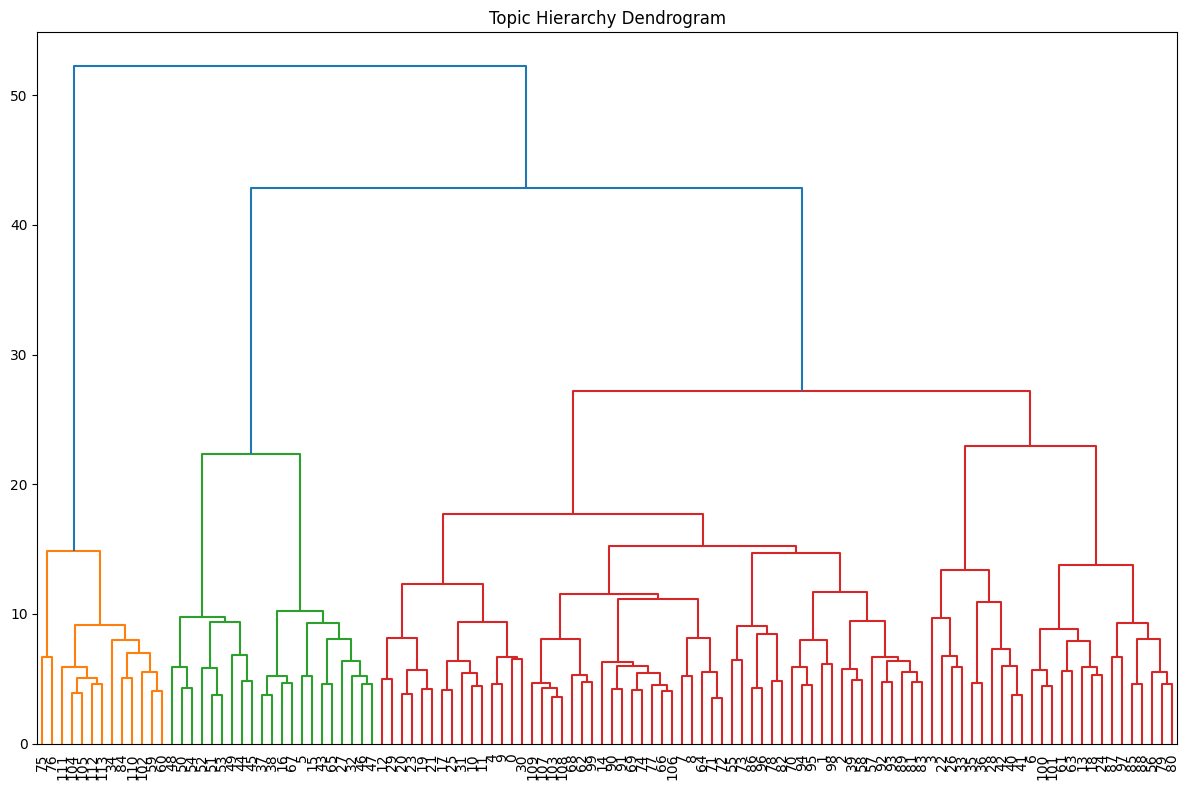

In [ ]:
# reduced topic-term matrix and topic labels
topic_matrix = topic_data.topic_term_matrix  # shape: (n_topics, vocab_size)
topic_labels = topic_data.topic_names        # list of strings or keywords per topic

# turn list of keywords into single string labels
# labels = [' | '.join(words[:3]) for words in topic_labels]

# Compute hierarchical clustering
linkage_matrix = linkage(topic_matrix, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=None, leaf_rotation=90, leaf_font_size=10)
plt.title("Topic Hierarchy Dendrogram")
plt.tight_layout()
plt.show()

### **Model 0:** Second dendrogram with cosine distance function

In [ ]:
# Extract topic names and embeddings from the model
topic_names = topic_data.topic_names
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['-1_biomarkers_biomarker_biochemistry_carcinogenesis',
  '0_retinopathy_glaucoma_intraocular_cataract',
  '1_infertility_intrauterine_infertile_ivf',
  '2_sensors_sensor_accelerometers_sensing',
  '3_insecticides_insecticide_pesticides_insect',
  '4_lignocellulosic_lignin_biomass_cellulose',
  '5_dental_teeth_periodontal_periodontitis',
  '6_dental_teeth_periodontal_tooth',
  '7_periodontitis_periodontal_gingival_dental',
  '8_toxins_aquaculture_toxicological_neurotoxicity',
  '9_candidiasis_candida_antifungal_aspergillus',
  '10_leishmaniasis_trypanosoma_proteases_pathogenesis',
  '11_pathogen_pathogens_enterobacteriaceae_malaria',
  '12_tuberculosis_hiv_tb_immunodeficiency',
  '13_dinucleotide_ligands_molecularly_biomolecules',
  '14_biosynthesis_glycolysis_hydroxylase_enzymes',
  '15_chemotherapeutics_phytochemicals_antiproliferative_antitumor',
  '16_antimicrobials_antimicrobial_antibacterial_antibiotic',
  '17_malaria_plasmodium_antimalarial_dengue',
  '18_interferon_antiviral_h

/tmp/ipython-input-40-2765003755.py:8: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



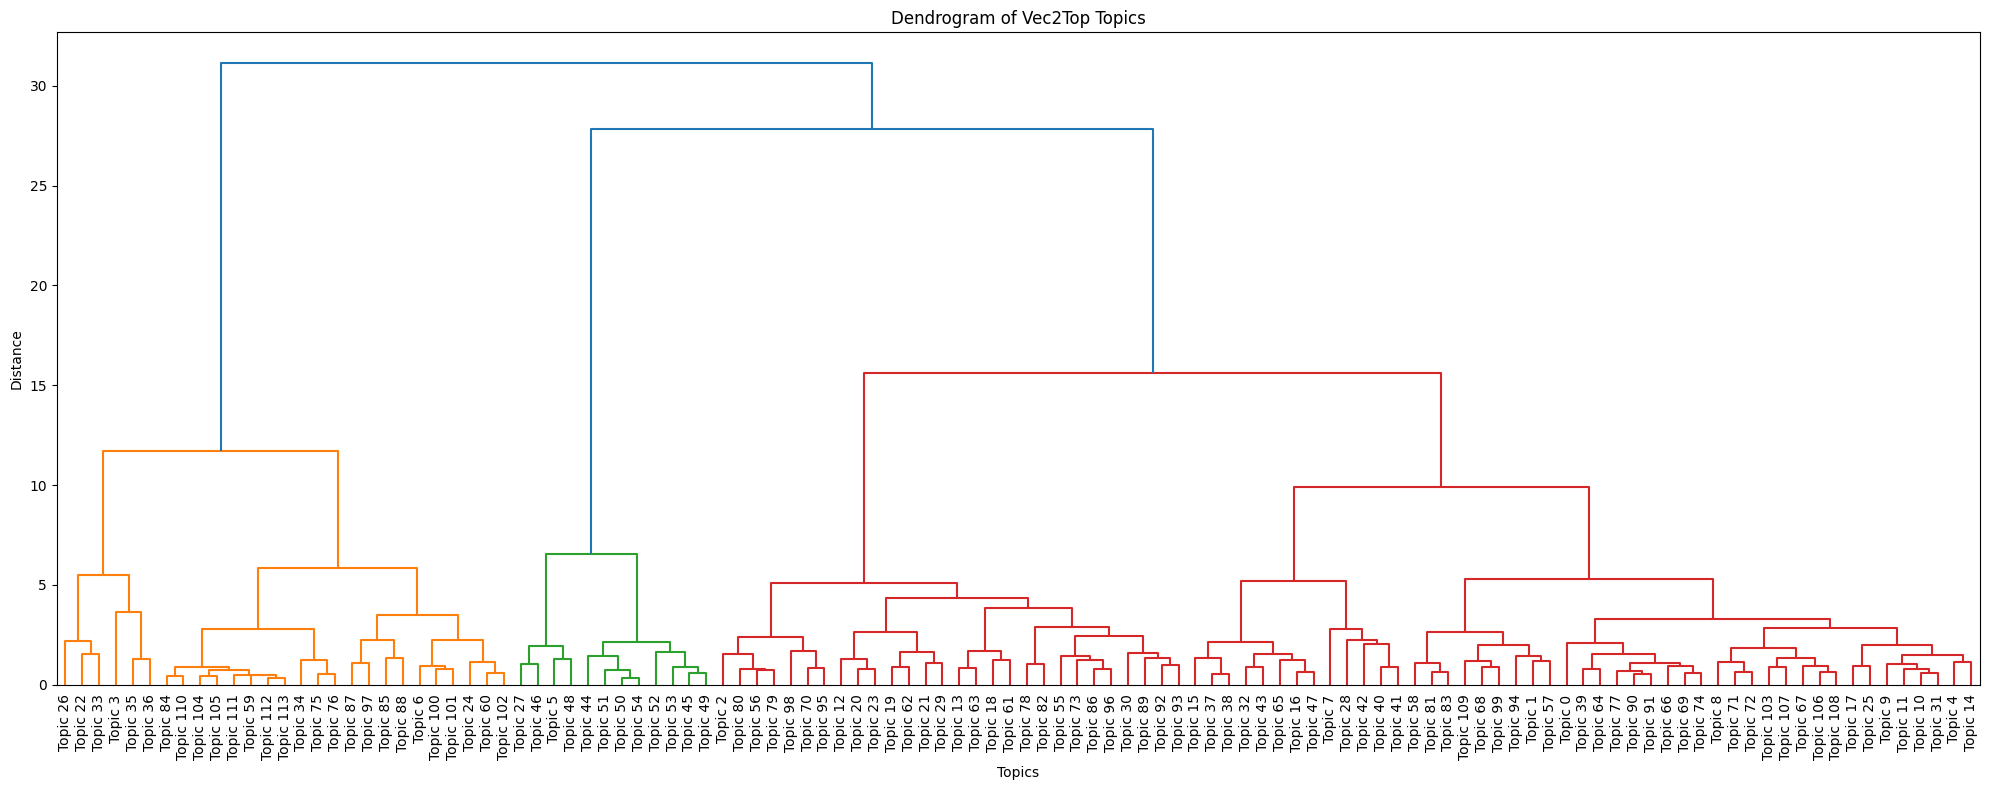

In [ ]:
# use document_topic_matrix if you'd rather visualize topics by their document composition
# topic_embeddings = model.document_topic_matrix.T  # shape: (num_topics, num_documents)

# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Step 3: Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(20, 8))
dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### **Model1:** First dendrogram without cosine distance function

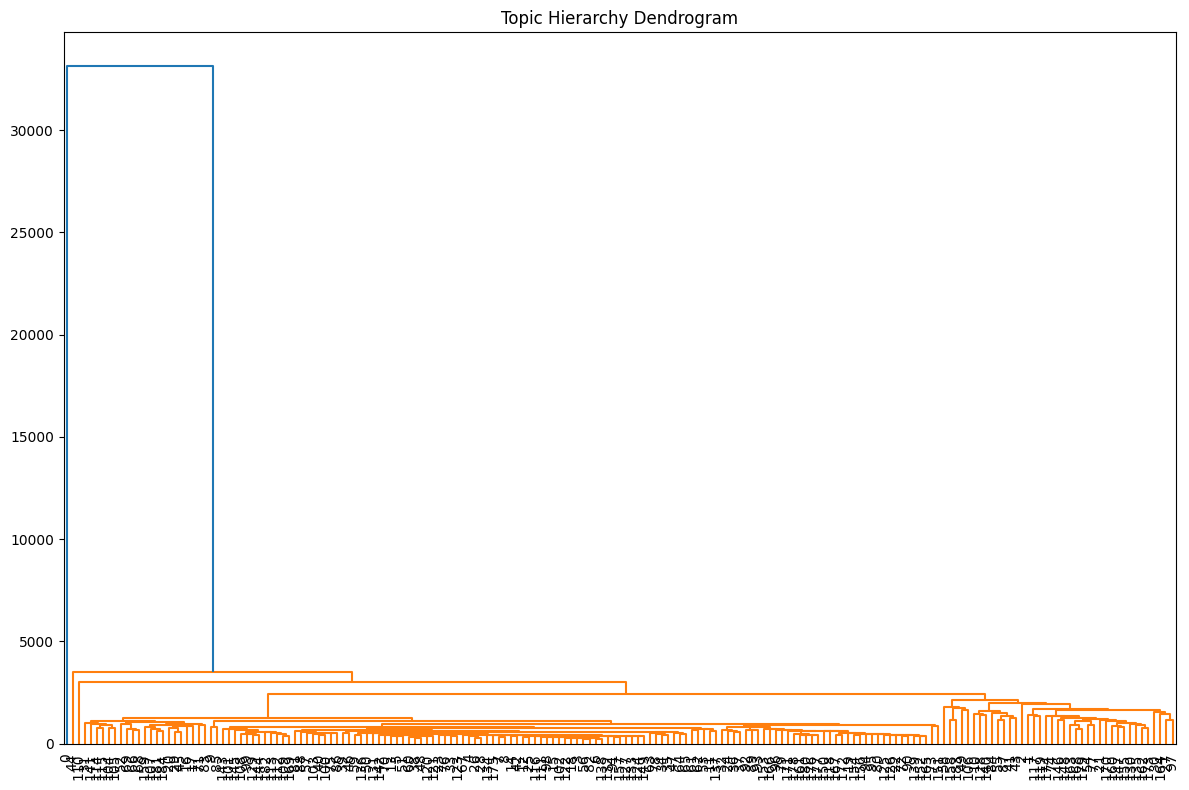

In [ ]:
# reduced topic-term matrix and topic labels
topic_matrix1 = topic_data1.topic_term_matrix  # shape: (n_topics, vocab_size)
topic_labels1 = topic_data1.topic_names        # list of strings or keywords per topic

# turn list of keywords into single string labels
# labels = [' | '.join(words[:3]) for words in topic_labels]

# Compute hierarchical clustering
linkage_matrix1 = linkage(topic_matrix1, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix1, labels=None, leaf_rotation=90, leaf_font_size=10)
plt.title("Topic Hierarchy Dendrogram")
plt.tight_layout()
plt.show()

### **Model 1:** Second dendrogram with cosine distance function

In [ ]:
# Extract topic names and embeddings from the model
topic_names1 = topic_data1.topic_names
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names1, topic_embeddings1

(['-1_study_patients_results_cells',
  '0_eyes_retinal_oct_eye',
  '1_pregnancy_embryo_ivf_embryos',
  '2_usepackage_document_termination_logic',
  '3_venom_snake_toxins_extracts',
  '4_reproduction_larvae_feeding_insect',
  '5_pest_insect_receptors_olfactory',
  '6_image_calibration_proposed_error',
  '7_emg_tactile_finger_force',
  '8_proposed_gnss_method_navigation',
  '9_iot_network_wireless_nodes',
  '10_usepackage_sensor_emotion_wearable',
  '11_membrane_cluster_proteins_colonies',
  '12_fish_mercury_diets_pb',
  '13_pretreatment_corn_biomass_pretreated',
  '14_tuberculosis_mycobacterium_mtb_drug',
  '15_albicans_fungal_candida_fluconazole',
  '16_parasite_leishmania_parasites_cruzi',
  '17_corn_milk_beef_contamination',
  '18_tetanus_vaccination_immunization_vaccine',
  '19_docking_binding_interactions_inhibitors',
  '20_tb_tuberculosis_mtb_rr',
  '21_hiv_antiretroviral_art_aids',
  '22_3d_printing_printed_phantom',
  '23_prevalence_intestinal_water_parasitic',
  '24_flow_les_pa

/tmp/ipython-input-46-732572678.py:8: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



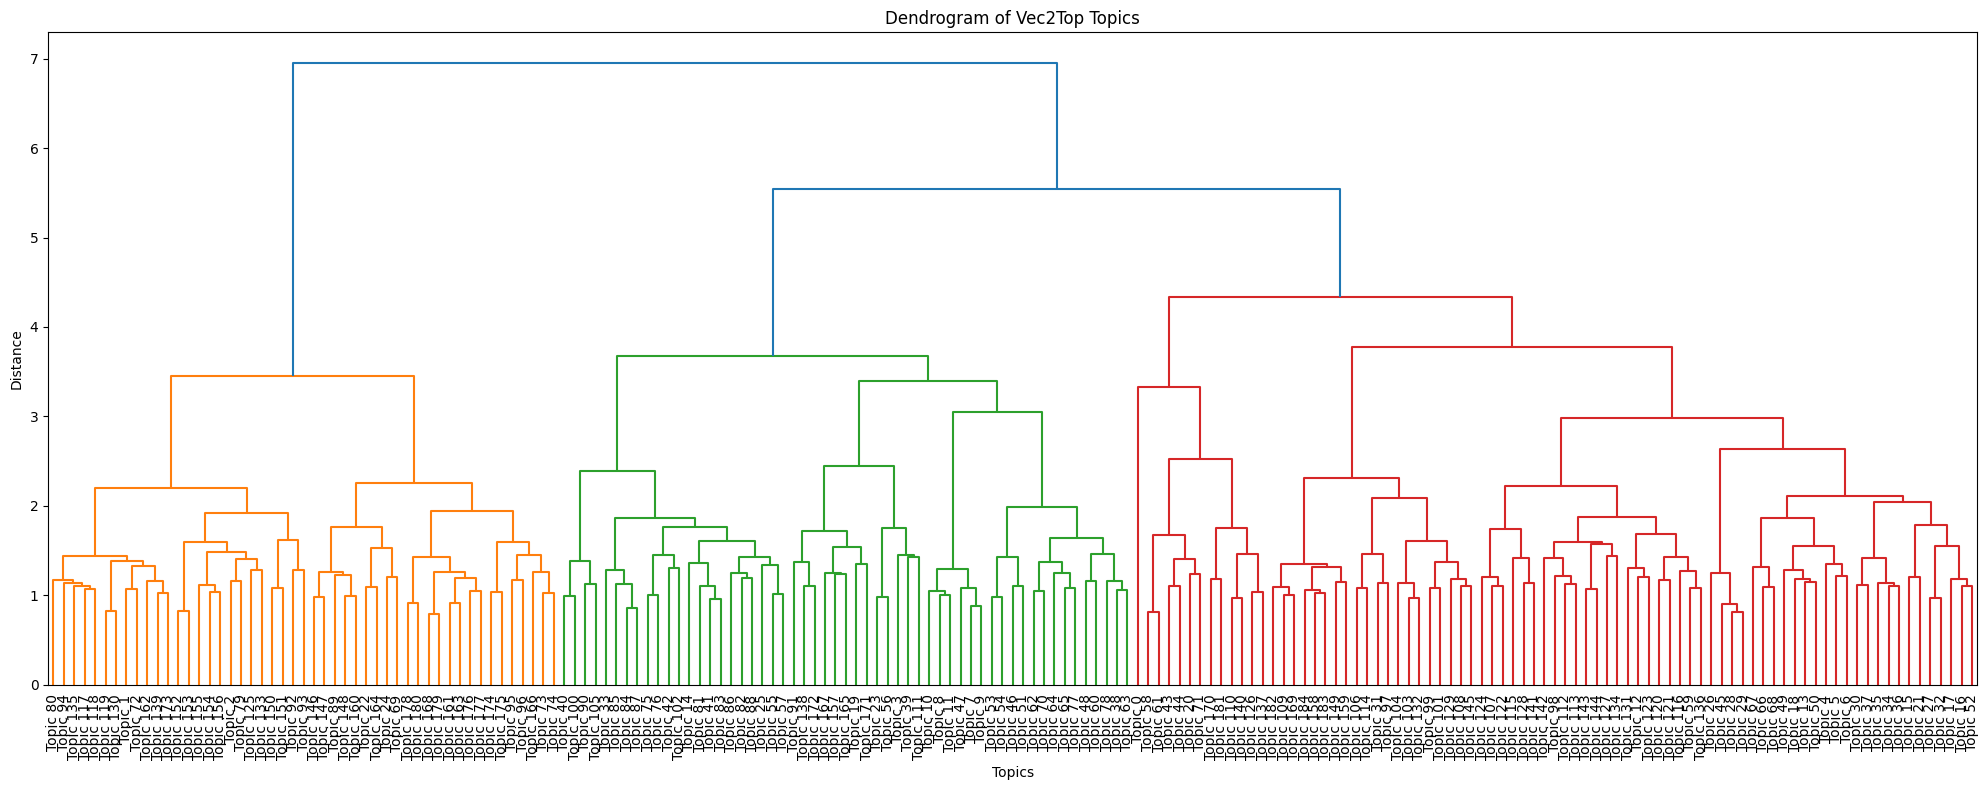

In [ ]:
# use document_topic_matrix if you'd rather visualize topics by their document composition
# topic_embeddings = model.document_topic_matrix.T  # shape: (num_topics, num_documents)

# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

# Step 3: Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(20, 8))
dendrogram(linkage_matrix1, labels=[f"Topic {i}" for i in range(len(topic_names1))], leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()